# Quantum-Classical Hybrid Autoencoder for Medical Image Classification

This notebook implements a hybrid quantum-classical model for chest X-ray classification.

## Installation (Run if packages missing)

In [1]:
# Uncomment and run if you need to install packages
#%pip install torch torchvision numpy pennylane medmnist timm matplotlib

## Imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from timm.layers import DropBlock2d
import time
from IPython.display import display, update_display

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"PennyLane version: {qml.__version__}")

c:\Users\sreev\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!
PyTorch version: 2.9.0+cu130
PennyLane version: 0.43.0


## Settings

In [ ]:
latent_dim = 512
img_size = 224               #(28, 64, 128, 224)
batch_size = 64
n_epochs = 100
n_workers = 2

print(f"Configuration:")
print(f"  Latent dimension: {latent_dim}")
print(f"  Image size: {img_size}x{img_size}")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {n_epochs}")
print(f"  Workers: {n_workers}")

Configuration:
  Qubits: 6
  Quantum Blocks: 1
  Layers per Block: 10
  Latent dimension: 512
  Image size: 224x224
  Batch size: 64
  Epochs: 100
  Workers: 2


## Load Data from preprocess.py

We import the data loaders from our preprocess.py file to ensure consistency.

In [4]:
# Import data loaders from preprocess.py
from preprocess import train_dataset, test_dataset

print(f"Data loaded successfully!")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Data loaded successfully!
Training samples: 78468
Test samples: 22433


Filter Out Double-Labels

In [5]:
from torch.utils.data import Subset, DataLoader, Dataset

# Filter training set and compute per-class positive counts
train_single_label_indices = []
pos_counts = torch.zeros(14, dtype=torch.float)
for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    if isinstance(label, np.ndarray):
        lab = torch.from_numpy(label)
    elif isinstance(label, torch.Tensor):
        lab = label
    else:
        lab = torch.tensor(label)
    lab = lab.squeeze()
    if lab.ndim == 0:
        if int(lab.item()) is not None:
            if 0 <= int(lab.item()) < 14:
                train_single_label_indices.append(i)
                pos_counts[int(lab.item())] += 1
    else:
        if lab.sum() == 1:
            train_single_label_indices.append(i)
            pos_counts += lab.float()

train_subset = Subset(train_dataset, train_single_label_indices)

# Filter test set
test_single_label_indices = []
for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    if isinstance(label, np.ndarray):
        lab = torch.from_numpy(label)
    elif isinstance(label, torch.Tensor):
        lab = label
    else:
        lab = torch.tensor(label)
    lab = lab.squeeze()
    if lab.ndim == 0:
        if int(lab.item()) is not None:
            if 0 <= int(lab.item()) < 14:
                test_single_label_indices.append(i)
                pos_counts[int(lab.item())] += 1
    else:
        if lab.sum() == 1:
            test_single_label_indices.append(i)
            pos_counts += lab.float()

test_subset = Subset(test_dataset, test_single_label_indices)


In [ ]:
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=n_workers, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=n_workers, pin_memory=True, persistent_workers=True)

print(f"Filtered Training: {len(train_subset)} single-label images ({len(train_loader)} batches)")
print(f"Filtered Test: {len(test_subset)} single-label images ({len(test_loader)} batches)")

Filtered Training: 78468 single-label images (337 batches)
Filtered Test: 22433 single-label images (98 batches)


## Classical Encoder

In [9]:
def ConvBNReLU(in_c, out_c, stride=1, k=3):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, k, stride=stride, padding=k//2, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True)
    )

class Encoder(nn.Module):
    def __init__(self, latent_dim=256, img_size=224):
        super().__init__()
        self.encoder = nn.Sequential(
            # 224×224 → 224×224
            ConvBNReLU(1, 32),
            ConvBNReLU(32, 32),            # extra conv before downsampling
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 224→112
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ConvBNReLU(64, 64),
            ConvBNReLU(64, 128),           # extra conv before downsampling
            nn.Conv2d(128, 128, 3, stride=2, padding=1), # 112→56
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            ConvBNReLU(128, 256),
            nn.Conv2d(256, 256, 3, stride=2, padding=1), # 56→28
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            ConvBNReLU(256, 512),
            nn.Conv2d(512, 512, 3, stride=2, padding=1), # 28→14
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            DropBlock2d(block_size=3, drop_prob=0.05),

            nn.AdaptiveAvgPool2d(7),
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, latent_dim),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.encoder(x)


## Autoencoder

In [10]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=64, img_size=224):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512 * 7 * 7),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (512, 7, 7)),

            # 7 → 14
            nn.ConvTranspose2d(512, 512, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # 14 → 28
            nn.ConvTranspose2d(512, 256, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 28 → 56
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 56 → 112
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 112 → 224 (final upsample)
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # refine output
            nn.Conv2d(32, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            # final 1-channel reconstruction
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid()
        )


    def forward(self, z):
        return self.decoder(z)

In [11]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64, img_size=224):
        super().__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

## Train Autoencoder

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(latent_dim=latent_dim, img_size=224).to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

train_losses, test_losses = [], []
best_test_loss = float('inf')
best_epoch = 0
best_model = None
epoch_times = []
epochs_since_improvement = 0
_first_plot_done = False
plot_display_id = "ae_training_plot"

best_test_loss = float("inf")
for epoch in range(25):
    start_time = time.time()

    model.train()
    train_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, _ = model(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            recon, _ = model(x)
            loss = criterion(recon, x)
            test_loss += loss.item() * x.size(0)
    test_loss /= len(test_loader.dataset)

    epoch_time = time.time() - start_time
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    epoch_times.append(epoch_time)

    # ---- Track Best ----
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        epochs_since_improvement = 0
        best_model = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
        }

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(8, 4))
    epochs_range = range(1, len(train_losses) + 1)
    ax.plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=3)
    ax.plot(epochs_range, test_losses, 'r-o', label='Test Loss', linewidth=2, markersize=3)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title('Autoencoder Training Progress', fontsize=14)
    plt.tight_layout()
    
    if not _first_plot_done:
        display(fig, display_id=plot_display_id)
        _first_plot_done = True
    else:
        update_display(fig, display_id=plot_display_id)
    plt.close(fig)

    print("=" * 80)
    print(f"Epoch {epoch} | {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.5f} | "
          f"Test Loss: {test_loss:.5f} | "
          f"Best: {best_test_loss:.5f} ({best_epoch})")


KeyboardInterrupt: 

In [ ]:
torch.save(model.encoder.state_dict(), "encoder.pt")
torch.save(model.state_dict(), "autoencoder.pt")

torch.save(model.encoder.state_dict(), "encoder_best.pt")
torch.save(model.state_dict(), "autoencoder_best.pt")

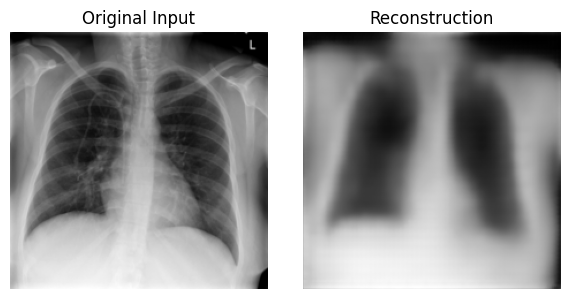

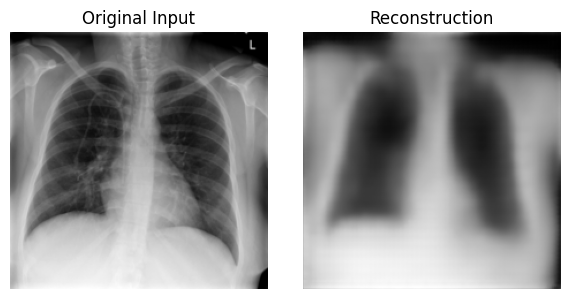

In [ ]:
def show_reconstruction_example(model_or_best, test_loader, device="cuda"):
    local_model = None
    # --- Load model if best_model dict was passed ---
    if isinstance(model_or_best, dict):
        # Determine latent_dim and img_size if not tracked externally
        # (You can adjust defaults here as needed)
        local_model = Autoencoder(latent_dim=latent_dim, img_size=224)
        local_model.load_state_dict(model_or_best["model_state_dict"])
    else:
        local_model = model_or_best

    local_model = local_model.to(device)
    local_model.eval()

    # --- Fetch one test batch ---
    x, _ = next(iter(test_loader))
    x = x.to(device)
    sample = x[:1]

    # --- Forward pass ---
    with torch.no_grad():
        recon, _ = local_model(sample)

    # --- Convert to numpy for visualization ---
    sample = sample.squeeze().detach().cpu().numpy()
    recon = recon.squeeze().detach().cpu().numpy()

    # --- Plot side-by-side ---
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(sample, cmap="gray")
    axs[0].set_title("Original Input")
    axs[0].axis("off")
    axs[1].imshow(recon, cmap="gray")
    axs[1].set_title("Reconstruction")
    axs[1].axis("off")
    plt.tight_layout()
    plt.show()

show_reconstruction_example(model, test_loader, device="cuda")
show_reconstruction_example(best_model, test_loader, device="cuda")